# Escolhendo a métrica pelo custo

**Tema:** Avaliação e Validação de Modelos › Métricas de Classificação

Um banco decide quais pedidos de empréstimo aprovar. Este notebook
transforma a decisão num problema de custo: matriz de custos, curva de
lucro por limiar, o limiar teórico $C_{FP}/(C_{FP}+C_{FN})$ contra o
empírico, o limiar de F1 contra o de lucro, a escolha entre dois modelos
pelo lucro, a restrição de capacidade e, por fim, custos que variam **por
exemplo** (o valor de cada empréstimo).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(613)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
JUROS, PERDA = 0.10, 0.70   # ganho se paga e perda se não paga, como fração do valor
print("pronto")

pronto


## 1. Os dados: pedidos de empréstimo

30.000 pedidos, com cerca de 20% de inadimplência. Cada pedido tem um
**valor**; o banco ganha 10% do valor em juros se o cliente paga e perde
70% do valor se o cliente não paga (a parte não recuperada na cobrança).
Aprovar todo mundo daria prejuízo: $0{,}8 \times 0{,}10 - 0{,}2 \times 0{,}70 < 0$.

In [2]:
n = 30000
renda = rng.lognormal(np.log(5000), 0.5, n)
comprometimento = rng.beta(2, 5, n)
atrasos = rng.poisson(0.5, n)
tempo_emprego = rng.exponential(5, n)
valor = (renda * rng.uniform(1, 6, n)).round(-2)
logit = -2.6 + 3.2 * comprometimento + 0.7 * atrasos - 0.08 * tempo_emprego \
    - 0.3 * (np.log(renda) - np.log(5000)) + rng.normal(0, 0.8, n)
inadimplente = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X = np.column_stack([np.log(renda), comprometimento, atrasos, tempo_emprego, np.log(valor)])
X_tr, X_te, y_tr, y_te, v_tr, v_te = train_test_split(X, inadimplente, valor, test_size=0.5,
                                                      random_state=0, stratify=inadimplente)
print(f"taxa de inadimplência: {inadimplente.mean():.1%} | valor mediano: R$ {np.median(valor):,.0f}")

taxa de inadimplência: 19.8% | valor mediano: R$ 16,500


## 2. A matriz de custos

"Positivo" = inadimplente. Decisão "positivo" = **negar** o empréstimo.

| | nega | aprova |
| :-- | :-- | :-- |
| **vai pagar** | FP: perde os juros (10% do valor) | VN: ganha os juros |
| **não vai pagar** | VP: evita a perda | FN: perde 70% do valor |

Em custo de oportunidade relativo à decisão perfeita: negar um bom
pagador custa $C_{FP} = 0{,}10 \cdot v$; aprovar um mau pagador custa
$C_{FN} = 0{,}70 \cdot v$. O limiar teórico é
$C_{FP}/(C_{FP}+C_{FN}) = 0{,}10/0{,}80 = 0{,}125$ — o valor $v$ se cancela.

limiar teórico: 0.125 | limiar empírico de lucro máximo: 0.130
limiar 0.125: lucro = R$   3.01 mi | aprovação = 28.1%
limiar 0.130: lucro = R$   3.07 mi | aprovação = 30.7%
limiar 0.500: lucro = R$ -11.81 mi | aprovação = 97.7%


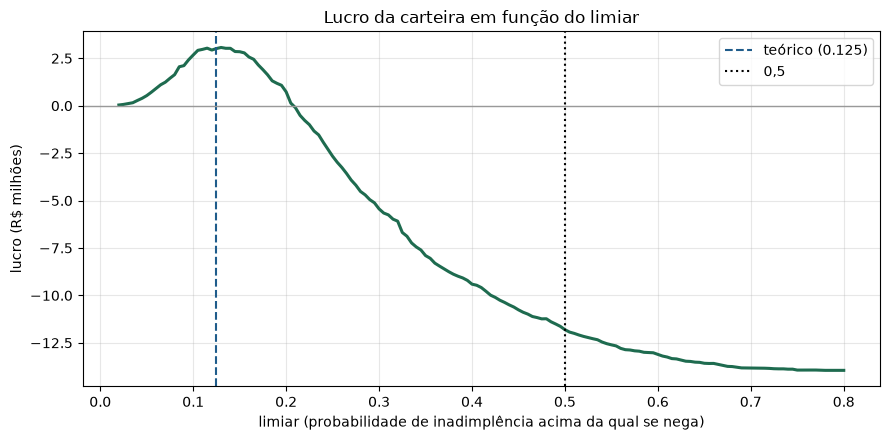

In [3]:
modelo = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
p = modelo.predict_proba(X_te)[:, 1]
t_teo = JUROS / (JUROS + PERDA)

def lucro(p, y, v, limiar):
    aprova = p < limiar
    return np.sum(np.where(aprova & (y == 0), JUROS * v, 0) - np.where(aprova & (y == 1), PERDA * v, 0))

limiares = np.linspace(0.02, 0.8, 157)
lucros = np.array([lucro(p, y_te, v_te, t) for t in limiares])
t_emp = limiares[np.argmax(lucros)]
print(f"limiar teórico: {t_teo:.3f} | limiar empírico de lucro máximo: {t_emp:.3f}")
for t in [t_teo, t_emp, 0.5]:
    print(f"limiar {t:.3f}: lucro = R$ {lucro(p, y_te, v_te, t) / 1e6:6.2f} mi | "
          f"aprovação = {(p < t).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(limiares, lucros / 1e6, color=VERDE, lw=2.2)
ax.axvline(t_teo, color=AZUL, ls="--", label=f"teórico ({t_teo:.3f})")
ax.axvline(0.5, color="black", ls=":", label="0,5")
ax.axhline(0, color="#999999", lw=1)
ax.set_xlabel("limiar (probabilidade de inadimplência acima da qual se nega)")
ax.set_ylabel("lucro (R$ milhões)"); ax.legend()
ax.set_title("Lucro da carteira em função do limiar")
plt.tight_layout(); plt.show()

## 3. O limiar de F1 máximo contra o de lucro máximo

In [4]:
f1s = [f1_score(y_te, (p >= t).astype(int)) for t in limiares]
t_f1 = limiares[int(np.argmax(f1s))]
print(f"limiar de F1 máximo  : {t_f1:.3f} -> lucro R$ {lucro(p, y_te, v_te, t_f1) / 1e6:.2f} mi")
print(f"limiar de lucro máximo: {t_emp:.3f} -> lucro R$ {lucros.max() / 1e6:.2f} mi")

limiar de F1 máximo  : 0.200 -> lucro R$ 0.73 mi
limiar de lucro máximo: 0.130 -> lucro R$ 3.07 mi


F1 supõe que precisão e recall valem o mesmo. Aqui um falso negativo
custa **sete** vezes um falso positivo, o limiar de lucro máximo fica bem
abaixo do de F1 máximo, e escolher pelo F1 deixa dinheiro na mesa.

## 4. Escolher o modelo pelo lucro, não só pela AUC

In [5]:
gb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=0).fit(X_tr, y_tr)
p_gb = gb.predict_proba(X_te)[:, 1]
for nome, pp in [("logística", p), ("boosting", p_gb)]:
    lucros_m = [lucro(pp, y_te, v_te, t) for t in limiares]
    print(f"{nome:>9s}: AUC = {roc_auc_score(y_te, pp):.4f} | lucro máximo = "
          f"R$ {max(lucros_m) / 1e6:.2f} mi no limiar {limiares[int(np.argmax(lucros_m))]:.3f}")

logística: AUC = 0.6954 | lucro máximo = R$ 3.07 mi no limiar 0.130
 boosting: AUC = 0.6836 | lucro máximo = R$ 2.50 mi no limiar 0.145


Aqui a logística vence nos dois critérios — com dados gerados por um
logit linear, ela é o modelo "certo". Note, porém, a escala: uma
diferença de uma casa decimal na AUC vira uma diferença mensurável em
reais. Quando as AUCs são próximas, é o lucro no ponto de operação que
decide, e ele não precisa concordar com a AUC — a AUC resume a curva
inteira, o lucro só enxerga o ponto em que se opera.

## 5. Capacidade: quando o limiar é imposto pela operação

Suponha que o time de análise manual só consegue revisar 3.000 pedidos
no período. A política vira: os 3.000 de maior risco vão para revisão (e
são negados); os demais são aprovados automaticamente.

In [6]:
k = 3000
top = np.argsort(-p)[:k]
limiar_k = np.sort(p)[::-1][k - 1]
print(f"limiar implícito pela capacidade: {limiar_k:.3f}  (o de lucro máximo era {t_emp:.3f})")
print(f"precisão@{k} = {y_te[top].mean():.3f} | recall@{k} = {y_te[top].sum() / y_te.sum():.3f}")
print(f"lucro com capacidade limitada: R$ {lucro(p, y_te, v_te, limiar_k + 1e-12) / 1e6:.2f} mi "
      f"(ótimo sem restrição: R$ {lucros.max() / 1e6:.2f} mi)")

limiar implícito pela capacidade: 0.277  (o de lucro máximo era 0.130)
precisão@3000 = 0.375 | recall@3000 = 0.378
lucro com capacidade limitada: R$ -4.36 mi (ótimo sem restrição: R$ 3.07 mi)


A capacidade força um limiar acima do ótimo — aqui, a ponto de
transformar uma carteira lucrativa em prejuízo, porque o banco passa a
aprovar muita gente que o modelo sabia ser arriscada. A curva de lucro
mede quanto essa restrição custa — um argumento concreto para ampliar o time
de análise, ou para **negar automaticamente** (sem revisão) a faixa de
risco em que o modelo tem alta confiança.

## 6. Custo dependente do exemplo

O limiar único supõe que a razão entre os custos é a mesma para todos —
o que é verdade enquanto os dois custos são proporcionais ao valor.
Acrescente um custo **fixo** de R$ 800 de análise e originação para cada
empréstimo aprovado, e o limiar ótimo passa a depender do valor:
aprovar vale a pena se o lucro esperado
$(1-p)(0{,}10\,v - 800) + p(-0{,}70\,v - 800)$ for positivo, isto é, se
$p < (0{,}10\,v - 800)/(0{,}80\,v)$.

Comparamos duas políticas, de forma honesta: o **melhor limiar único**,
escolhido no conjunto de **treino**, e a **decisão por exemplo** pelo lucro
esperado (que não tem nada a escolher). As duas são avaliadas no teste.

In [7]:
FIXO = 800

def lucro_com_fixo(aprova, y, v):
    return np.sum(np.where(aprova & (y == 0), JUROS * v - FIXO, 0)
                  + np.where(aprova & (y == 1), -PERDA * v - FIXO, 0))

p_tr = modelo.predict_proba(X_tr)[:, 1]
t_unico = limiares[int(np.argmax([lucro_com_fixo(p_tr < t, y_tr, v_tr) for t in limiares]))]
lucro_esperado = (1 - p) * (JUROS * v_te - FIXO) + p * (-PERDA * v_te - FIXO)
print(f"limiar único (escolhido no treino): {t_unico:.3f} -> lucro no teste "
      f"R$ {lucro_com_fixo(p < t_unico, y_te, v_te) / 1e6:.2f} mi")
print(f"decisão por exemplo (lucro esperado > 0): lucro no teste R$ "
      f"{lucro_com_fixo(lucro_esperado > 0, y_te, v_te) / 1e6:.2f} mi")
limiar_por_valor = pd.Series((JUROS * v_te - FIXO) / ((JUROS + PERDA) * v_te)).clip(lower=0)
print("\nlimiar implícito por faixa de valor (aprovar se p < limiar; 0 = nunca aprovar):")
print(limiar_por_valor.groupby(pd.qcut(v_te, 4)).median().round(3).to_string())

limiar único (escolhido no treino): 0.095 -> lucro no teste R$ 0.80 mi
decisão por exemplo (lucro esperado > 0): lucro no teste R$ 0.99 mi

limiar implícito por faixa de valor (aprovar se p < limiar; 0 = nunca aprovar):
(899.999, 10100.0]     0.000
(10100.0, 16500.0]     0.049
(16500.0, 26000.0]     0.077
(26000.0, 140000.0]    0.096


Um único split pode ser azarado (o livro dois do tema 4 mostrou quanto a
métrica varia entre splits). Repetimos a comparação em 10 divisões
diferentes:

In [8]:
vitorias, ganhos = 0, []
for s in range(10):
    Xa, Xb, ya, yb, va, vb = train_test_split(X, inadimplente, valor, test_size=0.5,
                                              random_state=s, stratify=inadimplente)
    m = LogisticRegression(max_iter=2000).fit(Xa, ya)
    pa, pb = m.predict_proba(Xa)[:, 1], m.predict_proba(Xb)[:, 1]
    tu = limiares[int(np.argmax([lucro_com_fixo(pa < t, ya, va) for t in limiares]))]
    le = (1 - pb) * (JUROS * vb - FIXO) + pb * (-PERDA * vb - FIXO)
    l_unico, l_ex = lucro_com_fixo(pb < tu, yb, vb), lucro_com_fixo(le > 0, yb, vb)
    vitorias += l_ex > l_unico
    ganhos.append((l_ex - l_unico) / 1e6)
print(f"decisão por exemplo venceu em {vitorias} de 10 divisões; "
      f"ganho médio de R$ {np.mean(ganhos):.2f} mi por carteira")

decisão por exemplo venceu em 10 de 10 divisões; ganho médio de R$ 0.39 mi por carteira


**Leitura esperada:** com o custo fixo, empréstimos pequenos precisam de
uma probabilidade de inadimplência bem menor para valerem a pena — os
menores nunca valem, porque os juros não pagam os R$ 800 —, e os grandes
toleram um risco maior. A regra por exemplo, derivada da mesma lógica de
custo esperado, supera o melhor limiar único de forma consistente. É essa a forma de decisão de muitos sistemas de crédito: a
probabilidade do modelo entra numa conta de **lucro esperado** caso a
caso, e a métrica que importa é o lucro da carteira. Isso só funciona se
a probabilidade for **calibrada** — tema do módulo 5.

## O que levar deste notebook

- A matriz de custos transforma "qual métrica?" em "quanto dinheiro?".
- O limiar teórico $C_{FP}/(C_{FP}+C_{FN})$ bate com o empírico quando as
  probabilidades são calibradas.
- Limiar de F1 máximo e limiar de lucro máximo raramente coincidem.
- Capacidade operacional impõe limiares; a curva de lucro diz quanto isso
  custa.
- Com custos que variam por exemplo, decida por lucro esperado caso a
  caso.

→ Próximo: **Exercícios** do módulo.